In [31]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

In [32]:
# 파일 경로 정의
file1_path = './testset/disaster_score1.json'
file2_path = './testset/disaster_score2.json'
output_path = './testset/disaster_score.json'

try:
    # 파일 읽기 및 데이터 로드
    with open(file1_path, 'r', encoding='utf-8') as f1:
        data1 = json.load(f1)
        
    with open(file2_path, 'r', encoding='utf-8') as f2:
        data2 = json.load(f2)

    # 'detailed_results' 키에 해당하는 리스트만 추출하여 병합
    list1 = data1.get('detailed_results', [])
    list2 = data2.get('detailed_results', [])
    merged_detailed_results = list1 + list2

    # 병합된 리스트를 포함한 새로운 딕셔너리 생성
    # detailed_results만 갱신합니다.
    merged_data = data1.copy()
    merged_data['detailed_results'] = merged_detailed_results

    # 병합된 데이터를 새로운 JSON 파일로 저장
    with open(output_path, 'w', encoding='utf-8') as f_out:
        json.dump(merged_data, f_out, indent=4, ensure_ascii=False)
        
    print(f"✅ {output_path} 파일이 성공적으로 생성되었습니다.")
    print(f"✔️ 총 {len(merged_detailed_results)}개의 질문/답변 데이터가 병합되었습니다.")

except FileNotFoundError:
    print("❌ 파일을 찾을 수 없습니다. 파일 경로를 다시 확인해주세요.")
except json.JSONDecodeError:
    print("❌ 유효하지 않은 JSON 파일입니다. 파일 내용을 확인해주세요.")
except KeyError:
    print("❌ JSON 파일에 'detailed_results' 키가 없습니다. 데이터 구조를 확인해주세요.")

✅ ./testset/disaster_score.json 파일이 성공적으로 생성되었습니다.
✔️ 총 100개의 질문/답변 데이터가 병합되었습니다.


In [33]:
# 파일 경로 정의
file1_path = './testset/price_score1.json'
file2_path = './testset/sales_score2.json'
output_path = './testset/priceagent_score.json'

try:
    # 파일 읽기 및 데이터 로드
    with open(file1_path, 'r', encoding='utf-8') as f1:
        data1 = json.load(f1)
        
    with open(file2_path, 'r', encoding='utf-8') as f2:
        data2 = json.load(f2)

    # 'detailed_results' 키에 해당하는 리스트만 추출하여 병합
    list1 = data1.get('detailed_results', [])
    list2 = data2.get('detailed_results', [])
    merged_detailed_results = list1 + list2

    # 병합된 리스트를 포함한 새로운 딕셔너리 생성
    # detailed_results만 갱신합니다.
    merged_data = data1.copy()
    merged_data['detailed_results'] = merged_detailed_results

    # 병합된 데이터를 새로운 JSON 파일로 저장
    with open(output_path, 'w', encoding='utf-8') as f_out:
        json.dump(merged_data, f_out, indent=4, ensure_ascii=False)
        
    print(f"✅ {output_path} 파일이 성공적으로 생성되었습니다.")
    print(f"✔️ 총 {len(merged_detailed_results)}개의 질문/답변 데이터가 병합되었습니다.")

except FileNotFoundError:
    print("❌ 파일을 찾을 수 없습니다. 파일 경로를 다시 확인해주세요.")
except json.JSONDecodeError:
    print("❌ 유효하지 않은 JSON 파일입니다. 파일 내용을 확인해주세요.")
except KeyError:
    print("❌ JSON 파일에 'detailed_results' 키가 없습니다. 데이터 구조를 확인해주세요.")

✅ ./testset/priceagent_score.json 파일이 성공적으로 생성되었습니다.
✔️ 총 100개의 질문/답변 데이터가 병합되었습니다.


##### evaluation summary 부분은 내가 알아서 지워서 전처리함

In [34]:
#disaster agent json file -> dataframe
# JSON 파일 경로
file_path = './testset/disaster_score.json'

# JSON 파일 불러오기
with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

# 'detailed_results' 리스트를 DataFrame으로 변환
disaster_df = pd.DataFrame(data['detailed_results'])

# 변환된 DataFrame 출력
print(disaster_df.head())
print("\nDataFrame의 컬럼 목록:")
print(disaster_df.columns)
print(len(disaster_df))

                                      question  \
0                     여름철에 농작물에 미치는 영향은 무엇인가요?   
1  2020년부터 2024년까지 태풍으로 인한 농작물 피해 통계는 어떻게 되나요?   
2         농진청은 기후 변화에 따른 농작물 피해를 어떻게 대응하고 있나요?   
3                 농업기술원이 제공하는 재해 대응 기술은 무엇인가요?   
4                    영혼-디움이 농업에 미치는 영향은 무엇인가요?   

                                           reference  \
0  여름철에는 긴 장마와 고온으로 인해 농작물에 피해가 발생합니다. 특히, 과수의 개화...   
1  태풍 제8호 바비(8, 22.~27)와 제1호 태풍 하이선(9, 1.~7)으로 인해...   
2  농진청은 농업 기상 재해에 대한 모니터링과 피해 상황 파악을 통해 사전 및 사후 조...   
3  농업기술원은 재해 대응을 위한 다양한 기술 지원을 제공하며, 품목별 전문가로 구성된...   
4  영혼-디움은 농업 환경에서 기후 변화에 대응하기 위한 조기 경보 서비스와 지원을 제...   

                                              answer  \
0  안녕하세요! 여름철 농작물에 미치는 영향에 대해 이야기해볼까요? 여름은 농업에 있어...   
1  안녕하세요! 농업재해 및 작물 재해대응 정보에 대해 궁금하신 점이 있으시군요. 20...   
2  안녕하세요! 기후 변화에 따른 농작물 피해 대응에 대해 궁금하신 것 같네요. 농촌진...   
3  **개요**: 농업기술원에서는 기상재해에 대한 다양한 대응 기술을 제공하고 있습니다...   
4  안녕하세요! 농업재해 및 작물 재해대응 정보에 대해 궁금하신 점이 있으시군요. 특히...   

                         

In [35]:
# sales agent json file -> dataframe
# JSON 파일 경로
file_path = './testset/priceagent_score.json'

# JSON 파일 불러오기
with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

# 'detailed_results' 리스트를 DataFrame으로 변환
salesagent_df = pd.DataFrame(data['detailed_results'])

# 변환된 DataFrame 출력
print(salesagent_df.head())
print("\nDataFrame의 컬럼 목록:")
print(salesagent_df.columns)
print(len(salesagent_df))

                                            question  \
0                               방울토마토의 현재 가격은 얼마입니까?   
1  풋고추 10kg의 가격이 얼마인지 알고 싶어요. 그리고 가격이 어떻게 변했는지도 궁...   
2  복숭아/백도의 현재 가격은 얼마이며, 1개월 전 가격과 비교했을 때 어떤 변화가 있...   
3                                       피마늘 가격 얼마예요?   
4  최근 시금치의 가격 변동에 대해 자세히 설명해 주실 수 있습니까? 특히 어제, 1개...   

                                           reference  \
0  방울토마토/대추방울토마토 (1kg)의 가격은 현재 8,718원입니다. 이는 어제보다...   
1  풋고추(녹광 등) 10kg의 가격은 어제보다 8.8%(4250원) 감소한 43,90...   
2  복숭아/백도의 현재 가격은 23,200원이며, 이는 어제보다 1.4%(325원) 증...   
3      피마늘/난지(대서) (10kg)의 가격은 어제와 변동 없는 50,760원 입니다.   
4  시금치(4kg)의 가격은 어제보다 0.3%(260원) 증가하여 79,020원이 되었...   

                                              answer  \
0  방울토마토/대추방울토마토 (1kg)의 가격은 어제보다 5.7%(472원) 증가한 8...   
1  풋고추(10kg)의 가격에 대한 구체적인 정보는 확인되지 않았습니다. 현재로서는 풋...   
2  복숭아/백도 (4kg)의 가격은 어제보다 1.4%(325원) 증가한 23,200원입...   
3  피마늘/한지 (10kg)의 가격은 어제와 변동 없는 98,667원입니다. \n1개월...   
4  시금치(4kg)의 가격은 어제보다 0.3%(260원) 증가한 79,020원입니

In [36]:
# recommendation agent json file -> dataframe
# JSON 파일 경로
file_path = './testset/croprecommend_score.json'

# JSON 파일 불러오기
with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

# 'questions' 리스트를 DataFrame으로 변환
recommend_df = pd.DataFrame(data['questions'])

# 변환된 DataFrame 출력
print(recommend_df.head())
print("\nDataFrame의 컬럼 목록:")
print(recommend_df.columns)
print(len(recommend_df))

                                           question  \
0     비가 많이 오는 여름철에 작은 텃밭에서 잘 자랄 수 있는 작물 추천 부탁드립니다.   
1                초보자로서 작은 텃밭에서 기르기 좋은 작물 추천 부탁드립니다.   
2  저는 초보자로서 작은 텃밭을 가꾸고 싶은데, 이 환경에 적합한 작물 추천 부탁드립니다.   
3                            장마철에 적합한 작물 추천 부탁드립니다.   
4                  겨울철에 하우스에서 재배하기 좋은 작물 추천 부탁드립니다.   

                                              answer  \
0  여름철 비가 많이 오는 환경에서 작은 텃밭에서 잘 자랄 수 있는 작물로는 고추, 오...   
1  상추, 시금치, 당근 및 무를 추천드립니다. 상추는 생육이 빠르고 텃밭에서 쉽게 기...   
2  초보자로서 작은 텃밭을 가꾸고 싶으시다면, 상추, 시금치, 무, 그리고 당근을 추천...   
3  장마철에는 수분이 풍부하여 습기에 강한 작물이 잘 자랄 수 있습니다. 따라서 고구마...   
4  겨울철에 하우스에서 재배하기 좋은 작물로는 겨울철 재배에 적합한 채소들이 있습니다....   

                                       ragas_metrics pass_fail  
0  {'faithfulness': 0.0, 'answer_relevancy': 0.58...      PASS  
1  {'faithfulness': 0.0, 'answer_relevancy': 0.53...      PASS  
2  {'faithfulness': 0.0, 'answer_relevancy': 0.59...      PASS  
3  {'faithfulness': 0.0, 'answer_relevancy': 0.44...      PASS  
4  {'fa

In [37]:
# sales_df 확정

# 'individual_ragas_score' 컬럼을 평탄화하여 분리
df = pd.json_normalize(salesagent_df['individual_ragas_score'])

# 원래 DataFrame에 합치기
sales_df = pd.concat([salesagent_df.drop('individual_ragas_score', axis=1), df], axis=1)

print(sales_df.columns)
print(len(sales_df))

# 4개 지표 컬럼
metrics = ["faithfulness", "answer_relevancy", "context_recall", "context_precision"]

# 평균값 계산
avg_scores = sales_df[metrics].mean()

# 결과 출력
display(avg_scores)


Index(['question', 'reference', 'answer', 'context', 'timestamp',
       'context_precision', 'faithfulness', 'answer_relevancy',
       'context_recall'],
      dtype='object')
100


faithfulness         0.704360
answer_relevancy     0.490883
context_recall       0.720000
context_precision    0.750000
dtype: float64

In [38]:
# disasterA_df 확정

# 'individual_ragas_score' 컬럼을 평탄화하여 분리
df = pd.json_normalize(disaster_df['individual_ragas_score'])

# 원래 DataFrame에 합치기
disasterA_df = pd.concat([salesagent_df.drop('individual_ragas_score', axis=1), df], axis=1)

print(disasterA_df.columns)
print(len(disasterA_df))

# 4개 지표 컬럼
metrics = ["faithfulness", "answer_relevancy", "context_recall", "context_precision"]

# 평균값 계산
avg_scores = disasterA_df[metrics].mean()

# 결과 출력
display(avg_scores)


Index(['question', 'reference', 'answer', 'context', 'timestamp',
       'context_precision', 'faithfulness', 'answer_relevancy',
       'context_recall'],
      dtype='object')
100


faithfulness         0.904015
answer_relevancy     0.575110
context_recall       0.958333
context_precision    0.990000
dtype: float64

In [39]:
# recommendA_df 확정

# 'individual_ragas_score' 컬럼을 평탄화하여 분리
df = pd.json_normalize(recommend_df['ragas_metrics'])

# 원래 DataFrame에 합치기
recommendA_df = pd.concat([recommend_df.drop('ragas_metrics', axis=1), df], axis=1)

print(recommendA_df.columns)
print(len(recommendA_df))

# 4개 지표 컬럼
metrics = ["faithfulness", "answer_relevancy", "context_recall", "context_precision"]

# 평균값 계산
avg_scores = recommendA_df[metrics].mean()

# 결과 출력
display(avg_scores)


Index(['question', 'answer', 'pass_fail', 'faithfulness', 'answer_relevancy',
       'context_recall', 'context_precision', 'average'],
      dtype='object')
50


faithfulness         0.075846
answer_relevancy     0.606367
context_recall       0.725000
context_precision    0.034740
dtype: float64

In [40]:
# cropgrow_df 확정
cropgrow_df = pd.read_csv("./testset/cropgrow_score.csv")

# 4개 지표 컬럼
metrics = ["faithfulness", "answer_relevancy", "context_recall", "context_precision"]


print(cropgrow_df.columns)
print(len(cropgrow_df))

# 평균값 계산
avg_scores = cropgrow_df[metrics].mean()

# 결과 출력
display(avg_scores)

cropgrow_df.head()

Index(['gold_answer', 'faithfulness', 'answer_relevancy', 'context_recall',
       'context_precision', 'web_search_used', 'source_file'],
      dtype='object')
103


faithfulness         0.853242
answer_relevancy     0.885677
context_recall       0.787501
context_precision    0.931683
dtype: float64

,gold_answer,faithfulness,answer_relevancy,context_recall,context_precision,web_search_used,source_file
0,딸기를 재배할 때 생육 단계별로 적절한 온도를 관리하는 것은 매우 중요합니다. 생육...,0.944444,0.928362,0.8,1.0,no,딸기.pdf
1,"고구마 덩굴쪼김병을 예방하기 위해서는 몇 가지 재배 방법을 적용해야 합니다. 첫째,...",1.000000,0.911791,1.0,1.0,no,고구마.pdf
2,"흰가루병 예방을 위한 효과적인 재배 방법은 여러 가지가 있습니다. 첫째, 너무 조밀...",1.000000,0.877586,1.0,1.0,no,채소병해충 (병충해).pdf
3,라이족토니아균에 의해 발생하는 병해를 예방하기 위한 재배 방법은 다음과 같습니다. ...,0.695652,0.889523,1.0,1.0,yes,채소병해충 (병충해).pdf
4,"감자마른썩음병을 예방하기 위해서는 몇 가지 방제 방법이 있습니다. 첫째, 감자 식물...",0.000000,0.504932,1.0,1.0,no,감자.pdf


#### 데이터프레임 이름 
* cropgrow_df
* disasterA_df
* recommendA_df
* sales_df

### 평균 점수 정리

In [41]:
metrics = ["faithfulness", "answer_relevancy", "context_recall", "context_precision"]

# 평균값 계산
cropgrow_avg_scores = cropgrow_df[metrics].mean()

print("작물재배 agent Ragas 평균 점수")

# 결과 출력
display(cropgrow_avg_scores)


# 평균값 계산
disaster_avg_scores = disasterA_df[metrics].mean()

print("재해대응 agent Ragas 평균 점수")

# 결과 출력
display(disaster_avg_scores)


# 평균값 계산
recommend_avg_scores = recommendA_df[metrics].mean()

print("작물추천 agent Ragas 평균 점수")

# 결과 출력
display(recommend_avg_scores)

# 평균값 계산
sales_avg_scores = sales_df[metrics].mean()

print("판매처 agent Ragas 평균 점수")

# 결과 출력
display(sales_avg_scores)

작물재배 agent Ragas 평균 점수


faithfulness         0.853242
answer_relevancy     0.885677
context_recall       0.787501
context_precision    0.931683
dtype: float64

재해대응 agent Ragas 평균 점수


faithfulness         0.904015
answer_relevancy     0.575110
context_recall       0.958333
context_precision    0.990000
dtype: float64

작물추천 agent Ragas 평균 점수


faithfulness         0.075846
answer_relevancy     0.606367
context_recall       0.725000
context_precision    0.034740
dtype: float64

판매처 agent Ragas 평균 점수


faithfulness         0.704360
answer_relevancy     0.490883
context_recall       0.720000
context_precision    0.750000
dtype: float64

### 레이더 차트 시각화 (개별 시각화)

In [42]:
# 레이더 차트 시각화 함수
def radarplot_ragas_scores(df, agent_name):
    # 한글 폰트 설정
    plt.rc('font', family='Malgun Gothic')
    plt.rcParams['axes.unicode_minus'] = False
    
    # 시각화에 사용할 지표
    metrics = ["faithfulness", "answer_relevancy", "context_recall", "context_precision"]
    
    # ---------------------------
    # 지표별 평균 계산
    # ---------------------------
    avg_scores = df[metrics].mean().tolist()
    avg_scores += avg_scores[:1]  # 시작점과 끝점 연결

    # 각 지표를 원형으로 배치
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]
    # ---------------------------
    # 레이더 차트 그리기
    # ---------------------------
    fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
    ax.plot(angles, avg_scores, "o-", linewidth=2, label="Average Scores")
    ax.fill(angles, avg_scores, alpha=0.25)

    # 축 세팅
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=12)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2","0.4","0.6","0.8","1.0"])
    ax.set_ylim(0, 1)

    # 제목
    plt.title(f"{agent_name} Agent Ragas 지표 평균 점수") 

    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

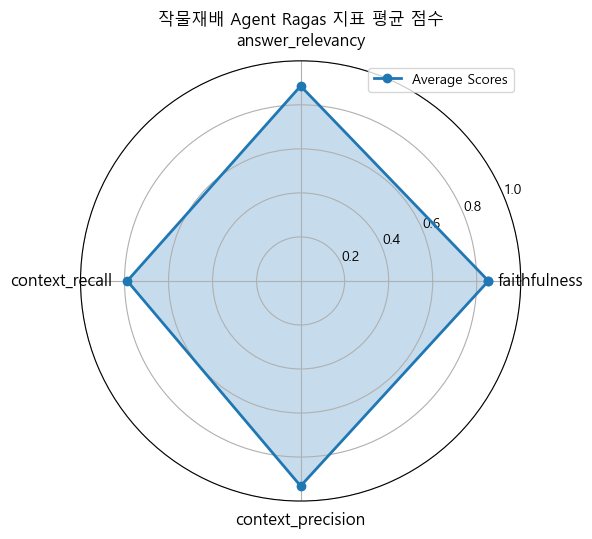

In [43]:
radarplot_ragas_scores(cropgrow_df, "작물재배")

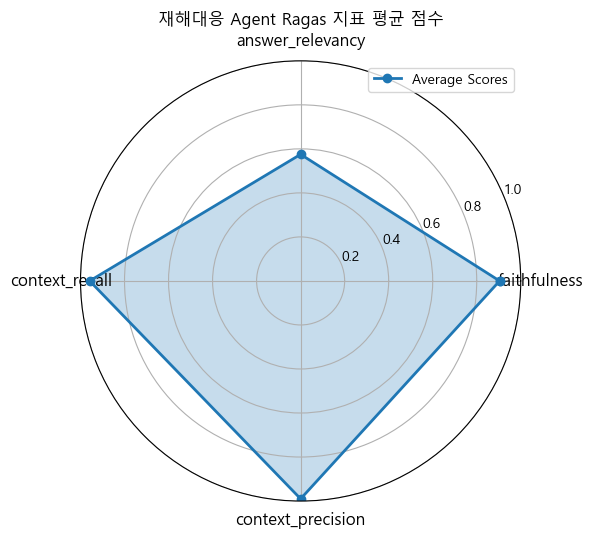

In [44]:
radarplot_ragas_scores(disasterA_df, "재해대응")

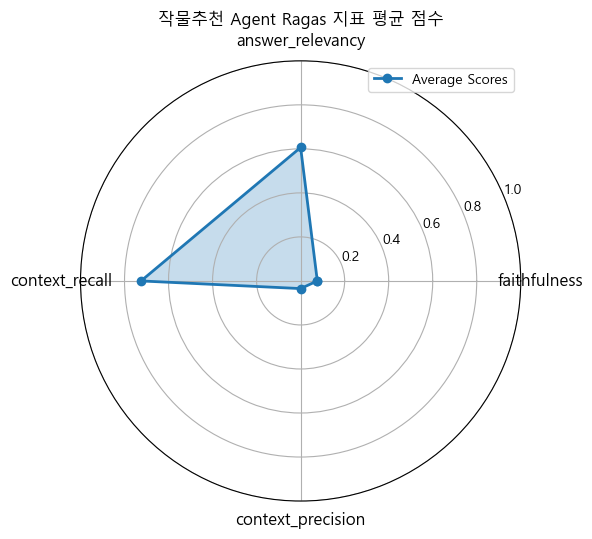

In [45]:
radarplot_ragas_scores(recommendA_df, "작물추천")

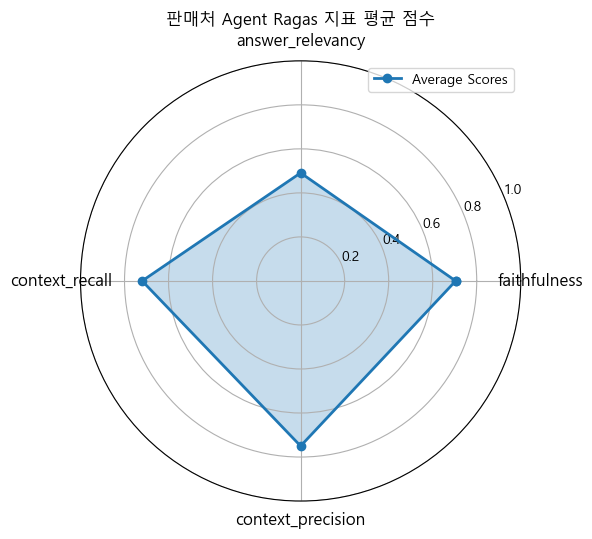

In [46]:
radarplot_ragas_scores(sales_df, "판매처")

### 레이더 차트 시각화 (4개의 에이전트)

In [47]:
def radarplot_ragas_scores_multiple(dfs, agent_names):
    """
    여러 에이전트의 RAGAS 점수를 계산하고 하나의 레이더 차트로 시각화하는 함수.

    Args:
        dfs (list): RAGAS 점수 데이터가 포함된 DataFrame 리스트.
        agent_names (list): 각 DataFrame에 해당하는 에이전트의 이름 리스트.
    """
    # 한글 폰트 설정
    plt.rc('font', family='Malgun Gothic')
    plt.rcParams['axes.unicode_minus'] = False
    
    # 시각화에 사용할 지표
    metrics = ["faithfulness", "answer_relevancy", "context_recall", "context_precision"]
    
    # ---------------------------
    # 레이더 차트 그리기 준비
    # ---------------------------
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # 각 지표를 원형으로 배치
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1] # 시작점과 끝점 연결

    # ---------------------------
    # 각 DataFrame의 평균 점수를 계산하고 그래프에 추가
    # ---------------------------
    for df, name in zip(dfs, agent_names):
        avg_scores = df[metrics].mean().tolist()
        avg_scores += avg_scores[:1]
        
        ax.plot(angles, avg_scores, "o-", linewidth=2, label=name)
        ax.fill(angles, avg_scores, alpha=0.25)
    
    # 축 세팅
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=12)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2","0.4","0.6","0.8","1.0"], color="gray")
    ax.set_ylim(0, 1)
    
    # 제목 및 범례
    plt.title("Ragas 지표 비교", fontsize=16, pad=20)
    plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
    plt.tight_layout()
    plt.show()

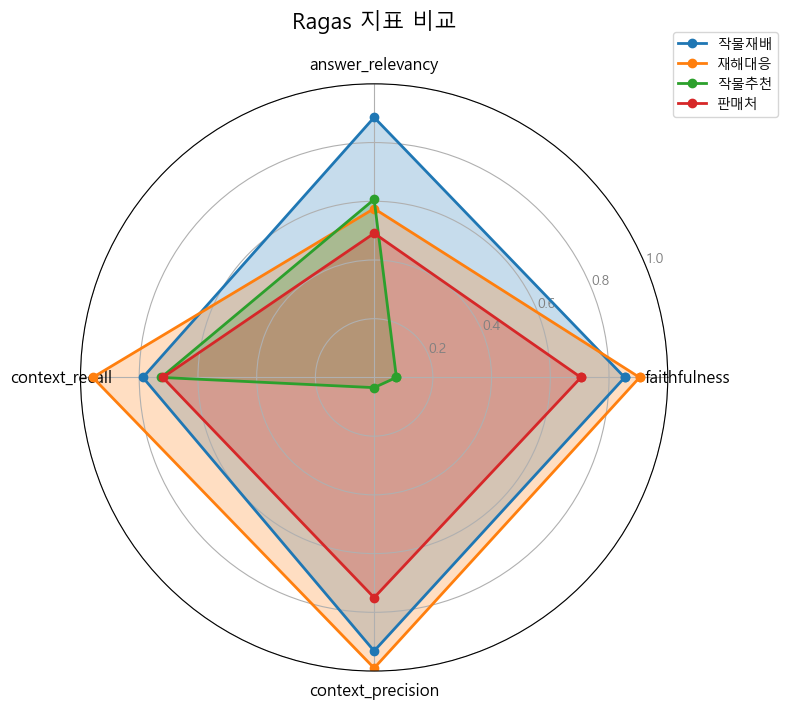

In [48]:
# DataFrame 리스트와 에이전트 이름 리스트를 정의
dfs_to_plot = [cropgrow_df, disasterA_df, recommendA_df, sales_df]
agent_names_to_plot = ["작물재배", "재해대응", "작물추천", "판매처"]

# 함수 호출
radarplot_ragas_scores_multiple(dfs_to_plot, agent_names_to_plot)

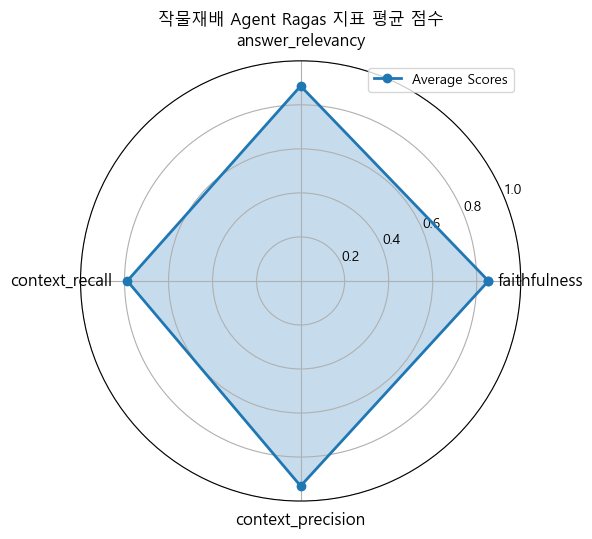

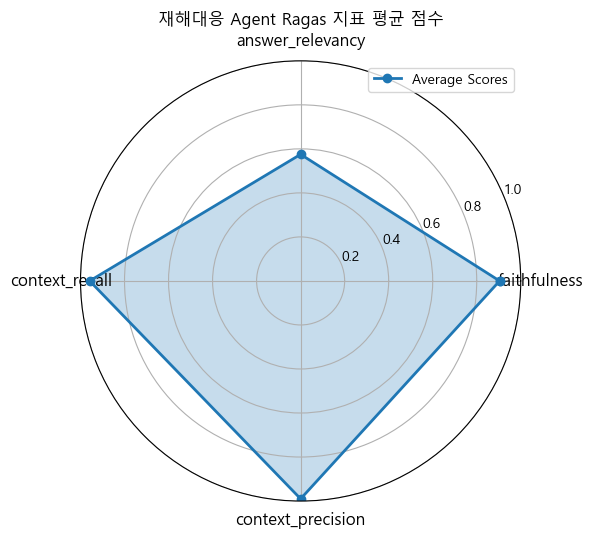

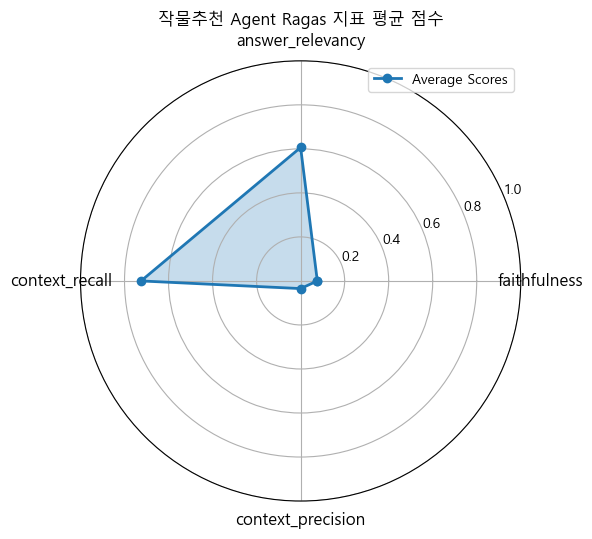

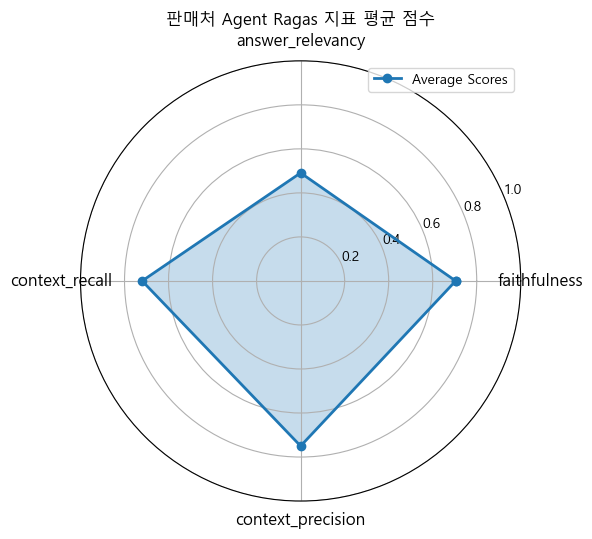

In [49]:
dfs = [cropgrow_df, disasterA_df, recommendA_df, sales_df]
agent_names = ["작물재배", "재해대응", "작물추천", "판매처"]

for d, name in zip(dfs, agent_names):
    radarplot_ragas_scores(d, name)  # 함수 그대로 호출


### 막대 그래프 시각화 (개별 시각화)

In [50]:
# 막대그래프 시각화 함수
def barplot_ragas_scores(df, agent_name):
    """
    RAGAS 점수의 평균을 계산하고 막대 그래프로 시각화하는 함수.

    Args:
        df (pd.DataFrame): RAGAS 점수 데이터가 포함된 DataFrame.
        agent_name (str): 그래프 제목에 들어갈 에이전트의 이름.
    """
    
    # 한글 폰트 설정
    plt.rc('font', family='Malgun Gothic')
    plt.rcParams['axes.unicode_minus'] = False
    
    # RAGAS 점수 컬럼의 평균 계산
    scores = df[["faithfulness", "answer_relevancy", "context_recall", "context_precision"]].mean()

    # 막대 그래프 그리기
    plt.figure(figsize=(8, 5))
    plt.bar(scores.index, scores.values, color=['skyblue', 'salmon', 'lightgreen', 'gold'])

    # 축 라벨과 제목 설정
    plt.xlabel("Ragas 점수 항목")
    plt.ylabel("평균 점수")
    plt.title(f"{agent_name} Agent 평균 점수") 
    plt.ylim(0, 1.1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

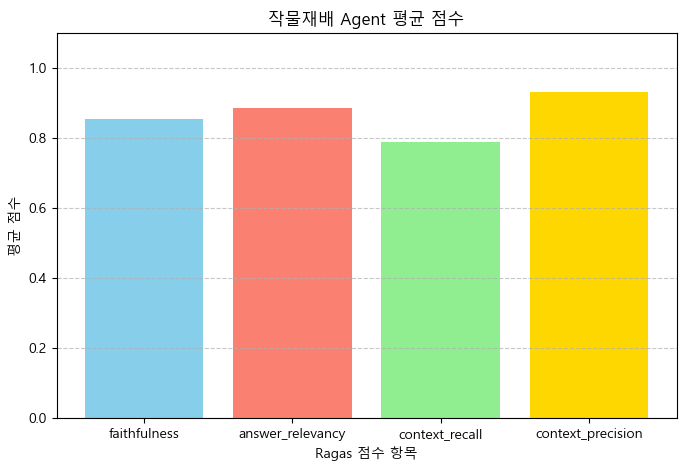

In [51]:
barplot_ragas_scores(cropgrow_df, "작물재배")

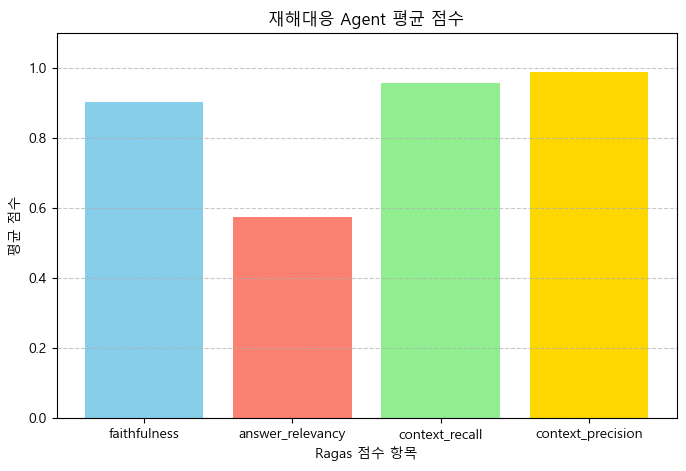

In [52]:
barplot_ragas_scores(disasterA_df, "재해대응")

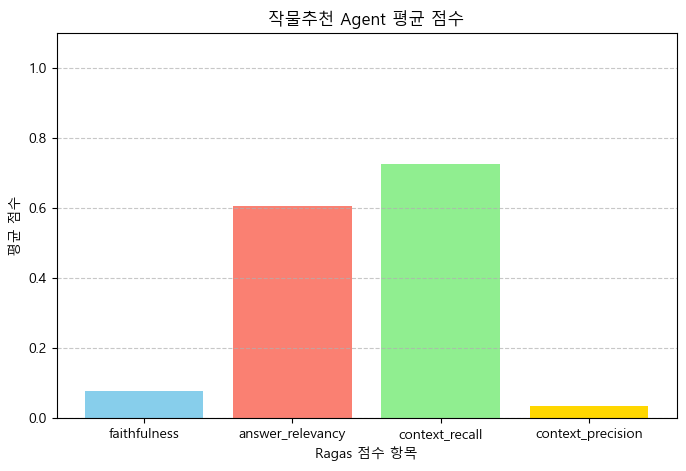

In [53]:
barplot_ragas_scores(recommendA_df, "작물추천")

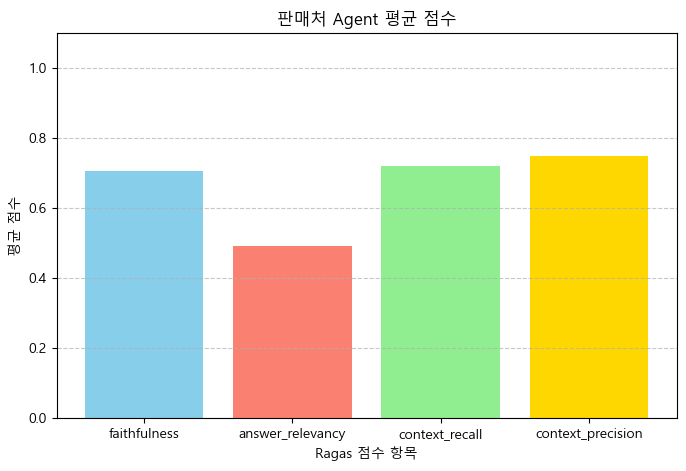

In [54]:
barplot_ragas_scores(sales_df, "판매처")

### 막대 그래프 시각화 (4개의 에이전트)

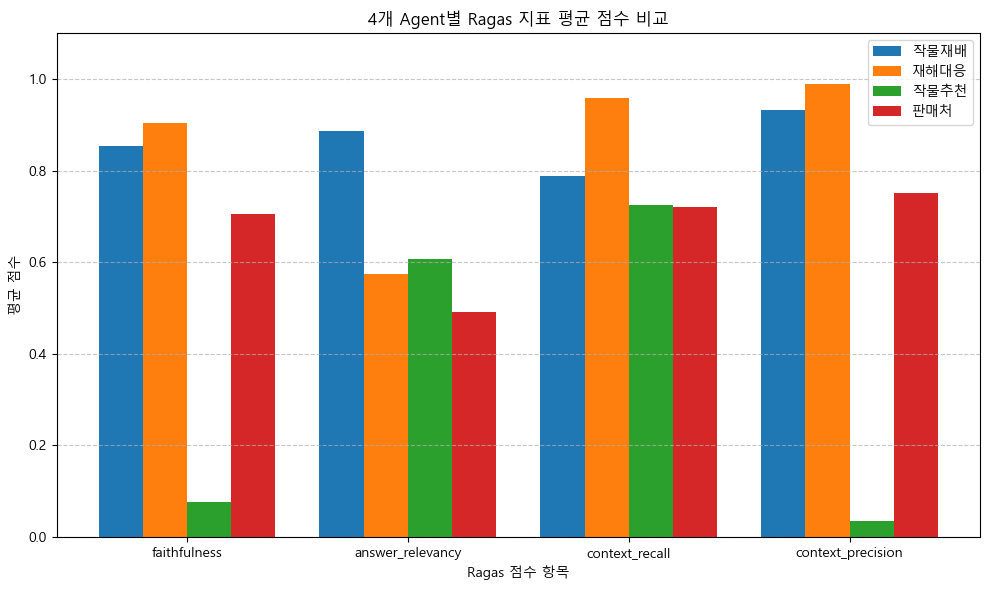

In [55]:
dfs = [cropgrow_df, disasterA_df, recommendA_df, sales_df]
agent_names = ["작물재배", "재해대응", "작물추천", "판매처"]
metrics = ["faithfulness", "answer_relevancy", "context_recall", "context_precision"]

# 각 df의 평균 점수 계산
scores_list = [df[metrics].mean().values for df in dfs]

# x 위치 (지표 4개)
x = np.arange(len(metrics))
bar_width = 0.2  

plt.figure(figsize=(10, 6))

# df별로 막대 그리기
for i, (scores, name) in enumerate(zip(scores_list, agent_names)):
    plt.bar(x + i * bar_width, scores, width=bar_width, label=name)

# 축, 제목, 범례
plt.xticks(x + bar_width * (len(dfs)-1) / 2, metrics)  # x축 중앙에 지표 이름
plt.xlabel("Ragas 점수 항목")
plt.ylabel("평균 점수")
plt.title("4개 Agent별 Ragas 지표 평균 점수 비교")
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


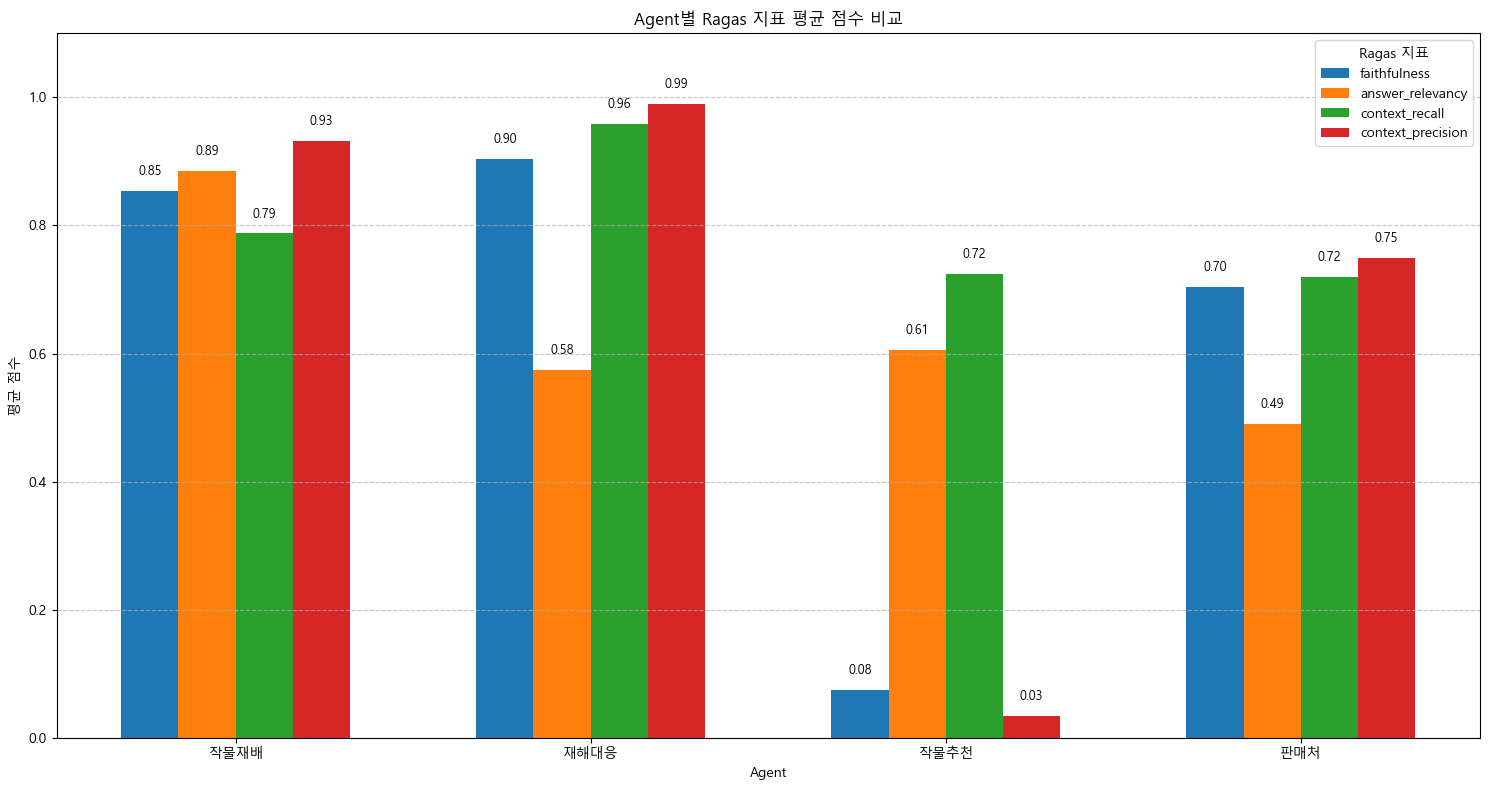

In [58]:
# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 시각화에 사용할 지표
metrics = ["faithfulness", "answer_relevancy", "context_recall", "context_precision"]

dfs = [cropgrow_df, disasterA_df, recommendA_df, sales_df]
agent_names = ["작물재배", "재해대응", "작물추천", "판매처"]
agent_colors = ['skyblue', 'salmon', 'lightgreen', 'gold']

# x축 위치와 막대 너비 설정
bar_width = 0.5
bar_spacing = 0.2
total_width = len(metrics) * bar_width + bar_spacing * (len(metrics) - 1)
x = np.arange(len(agent_names)) * (total_width + 0.5)

plt.figure(figsize=(15, 8))

# 각 지표별로 막대 그리기
for i, metric in enumerate(metrics):
    plt.bar(x + i * bar_width, [df[metric].mean() for df in dfs], 
            width=bar_width, label=metric)

# 각 막대 위에 값 표시
for i, metric in enumerate(metrics):
    for j, df in enumerate(dfs):
        value = df[metric].mean()
        plt.text(x[j] + i*bar_width, value + 0.02, f"{value:.2f}", ha='center', va='bottom', fontsize=9)

# 새로운 x축 레이블 생성 및 위치 조정
plt.xticks(x + (len(metrics) - 1) * bar_width / 2, agent_names)

plt.xlabel("Agent")
plt.ylabel("평균 점수")
plt.title("Agent별 Ragas 지표 평균 점수 비교")
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.legend(title='Ragas 지표')
plt.tight_layout()
plt.show()

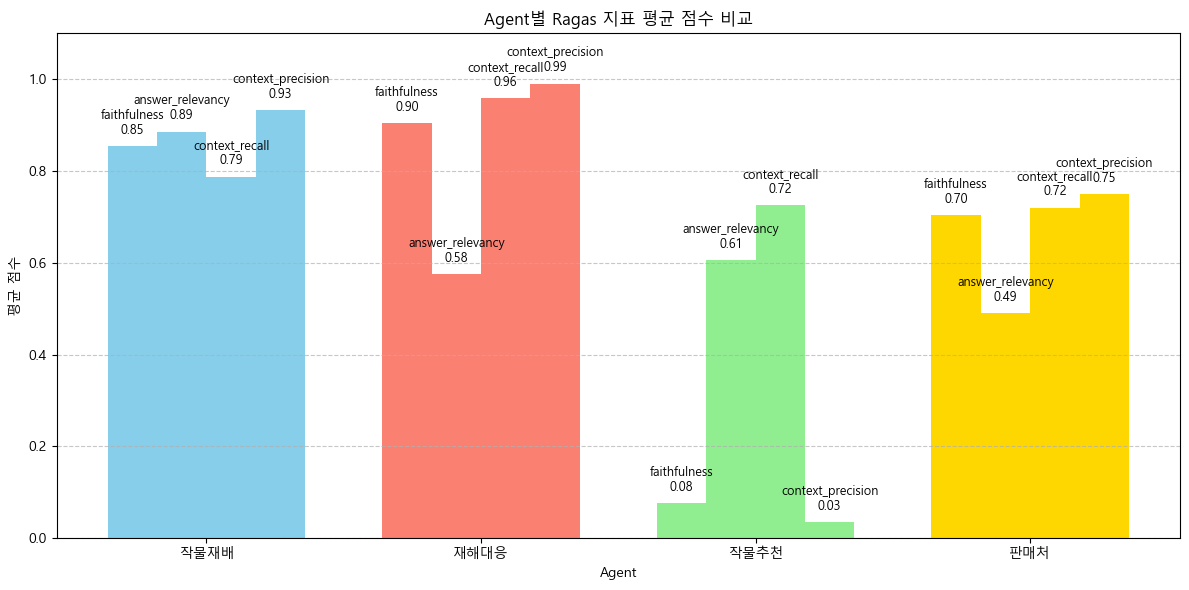

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dfs = [cropgrow_df, disasterA_df, recommendA_df, sales_df]
agent_names = ["작물재배", "재해대응", "작물추천", "판매처"]
metrics = ["faithfulness", "answer_relevancy", "context_recall", "context_precision"]
agent_colors = ['skyblue', 'salmon', 'lightgreen', 'gold']

x = np.arange(len(agent_names))  # agent 위치
bar_width = 0.18  # 지표별 막대 너비

plt.figure(figsize=(12, 6))

# 막대 그리기
for i, metric in enumerate(metrics):
    metric_scores = [df[metric].mean() for df in dfs]
    plt.bar(x + i * bar_width, metric_scores, 
            width=bar_width, color=agent_colors)

    # 막대 위에 점수와 지표 이름 표시
    for j, value in enumerate(metric_scores):
        plt.text(x[j] + i * bar_width, value + 0.02, f"{metric}\n{value:.2f}", 
                 ha='center', va='bottom', fontsize=9)

# x축 중앙에 agent 이름 표시
plt.xticks(x + bar_width * (len(metrics)-1)/2, agent_names)
plt.xlabel("Agent")
plt.ylabel("평균 점수")
plt.title("Agent별 Ragas 지표 평균 점수 비교")
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
